# Tutorial 4 — Real cross-protocol scRNA-seq (scIB pancreas)

This notebook reproduces the same comparison as Tutorial 3
but on real published data: the scIB human pancreas
benchmark from Luecken *et al.* 2022 (Nature Methods,
[DOI 10.1038/s41592-021-01336-8](https://doi.org/10.1038/s41592-021-01336-8)).

**Data.** 16,382 pancreatic islet cells across 9 published
protocol / batch labels (CEL-seq, CEL-seq2, Smart-seq2,
Fluidigm C1, Smarter, inDrop1–4). Library depth varies
~300× — Fluidigm C1 at ~1.2 M reads / cell, inDrop3 at
~3,800 UMI / cell. 14 published cell types.

The notebook uses a small stratified subsample
(`cells_per_cohort=5`) so it executes in ~2 min on CPU.
On first run the dataset is fetched from figshare
(~301 MB) and cached to `~/.cache/sparse-nmf/`. For the
production figure with `cells_per_cohort=12`, run
`python examples/real_pancreas_demo.py` from a shell.

In [1]:
import sys, pathlib
for _p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
    if (_p / 'examples' / 'real_pancreas_demo.py').exists():
        sys.path.insert(0, str(_p / 'examples'))
        break
else:
    raise RuntimeError('Could not locate the examples/ directory')
from _determinism import set_global_seed
set_global_seed(0)
from real_pancreas_demo import (
    load_pancreas, fit_pca, fit_nmf, fit_sparse_nmf,
    umap_project, depth_r2, make_figure,
)
import numpy as np, time
from sklearn.metrics import silhouette_score
from pathlib import Path

Seed set to 0


## Load the dataset

First call downloads + caches; subsequent calls are
instant. We use a small subsample so this notebook
completes in a reasonable time — the story holds at any
subsample size, only the absolute silhouette / R² numbers
shift slightly.

In [2]:
X, celltype, tech = load_pancreas(cells_per_cohort=5, seed=0)
n_counts = np.asarray(X.sum(axis=1)).ravel()
log_depth = np.log10(n_counts + 1.0)
print(f'X shape={X.shape}  nnz={X.nnz:,}  density={X.nnz / (X.shape[0]*X.shape[1]):.2%}')
print(f'{len(np.unique(celltype))} cell types, {len(np.unique(tech))} protocols')
print('depth (UMI/cell) by protocol:')
for tk in sorted(np.unique(tech)):
    d = n_counts[tech == tk]
    print(f'  {tk:>14s}: n={d.size:4d}  median={np.median(d):>10.0f}  '
          f'p10={np.percentile(d, 10):>10.0f}  p90={np.percentile(d, 90):>10.0f}')

X shape=(481, 19093)  nnz=1,676,744  density=18.26%
14 cell types, 9 protocols
depth (UMI/cell) by protocol:
          celseq: n=  45  median=      6948  p10=      4356  p90=     14881
         celseq2: n=  63  median=     16742  p10=      6769  p90=     40619
      fluidigmc1: n=  51  median=   1223356  p10=    639543  p90=   2126816
         inDrop1: n=  67  median=      4139  p10=      2274  p90=      9186
         inDrop2: n=  62  median=      4520  p10=      1906  p90=      7583
         inDrop3: n=  60  median=      3476  p10=      1792  p90=      8071
         inDrop4: n=  51  median=      5572  p10=      2470  p90=     10801
         smarter: n=  20  median=    424506  p10=    352338  p90=    492578
       smartseq2: n=  62  median=    310358  p10=     98113  p90=    698974


Note the depth column: Fluidigm C1 cells routinely report
1M+ reads / cell, while inDrop cells are at the ~4 k UMI
scale — three orders of magnitude apart. This is the
confound we're studying.

## Compare three factorizations

Same `k`, same UMAP, three different factorizations.
We report three metrics per method:

* **cell-type silhouette ↑** — does the embedding cluster
  by biology?
* **tech silhouette ↓ (near 0)** — are protocols mixed?
* **depth-R² ↓ (near 0)** — kNN R² for predicting
  log10(depth) from the 2-D UMAP. Quantifies how much of
  the depth axis is still encoded in the embedding. High
  is bad.

In [3]:
seed = 0
k = int(np.clip(min(X.shape) // 8, 32, 1024))
print(f'shared latent dim k={k}')

embeddings, metrics = {}, {}
for name, fn in (('PCA', fit_pca), ('NMF', fit_nmf), ('sparseNMF', fit_sparse_nmf)):
    t0 = time.time()
    high = fn(X, seed, k)
    z = umap_project(high, seed)
    embeddings[name] = z
    sg = float(silhouette_score(z, celltype))
    sb = float(silhouette_score(z, tech))
    r2 = depth_r2(z, log_depth)
    metrics[name] = (sg, sb, r2)
    print(f'  {name:>10s}: {time.time()-t0:6.1f}s  '
          f'silhouette(cell-type)={sg:+.3f}  '
          f'silhouette(tech)={sb:+.3f}  depth-R²={r2:+.3f}')

shared latent dim k=60


         PCA:    5.1s  silhouette(cell-type)=+0.030  silhouette(tech)=-0.079  depth-R²=+0.818


/Users/bschilder/Desktop/sparseNMF/.venv/lib/python3.11/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


         NMF:   28.5s  silhouette(cell-type)=+0.057  silhouette(tech)=-0.127  depth-R²=+0.632


/Users/bschilder/Desktop/sparseNMF/src/sparse_nmf/_core.py:339: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:767.)
  sparse_tensor = torch.sparse_coo_tensor(


   sparseNMF:   39.0s  silhouette(cell-type)=+0.265  silhouette(tech)=-0.130  depth-R²=+0.272


## Read the figure

Row 1: cell-type clusters. Row 2: tech mixing. Row 3 is
the smoking gun — color by `log10(UMI / cell)`. PCA / NMF
filaments resolve into clean depth gradients (purple low,
yellow high) — *the filaments are the depth axis*.
sparseNMF has depth scattered uniformly within each
cluster: the magnitude axis has been dissolved.

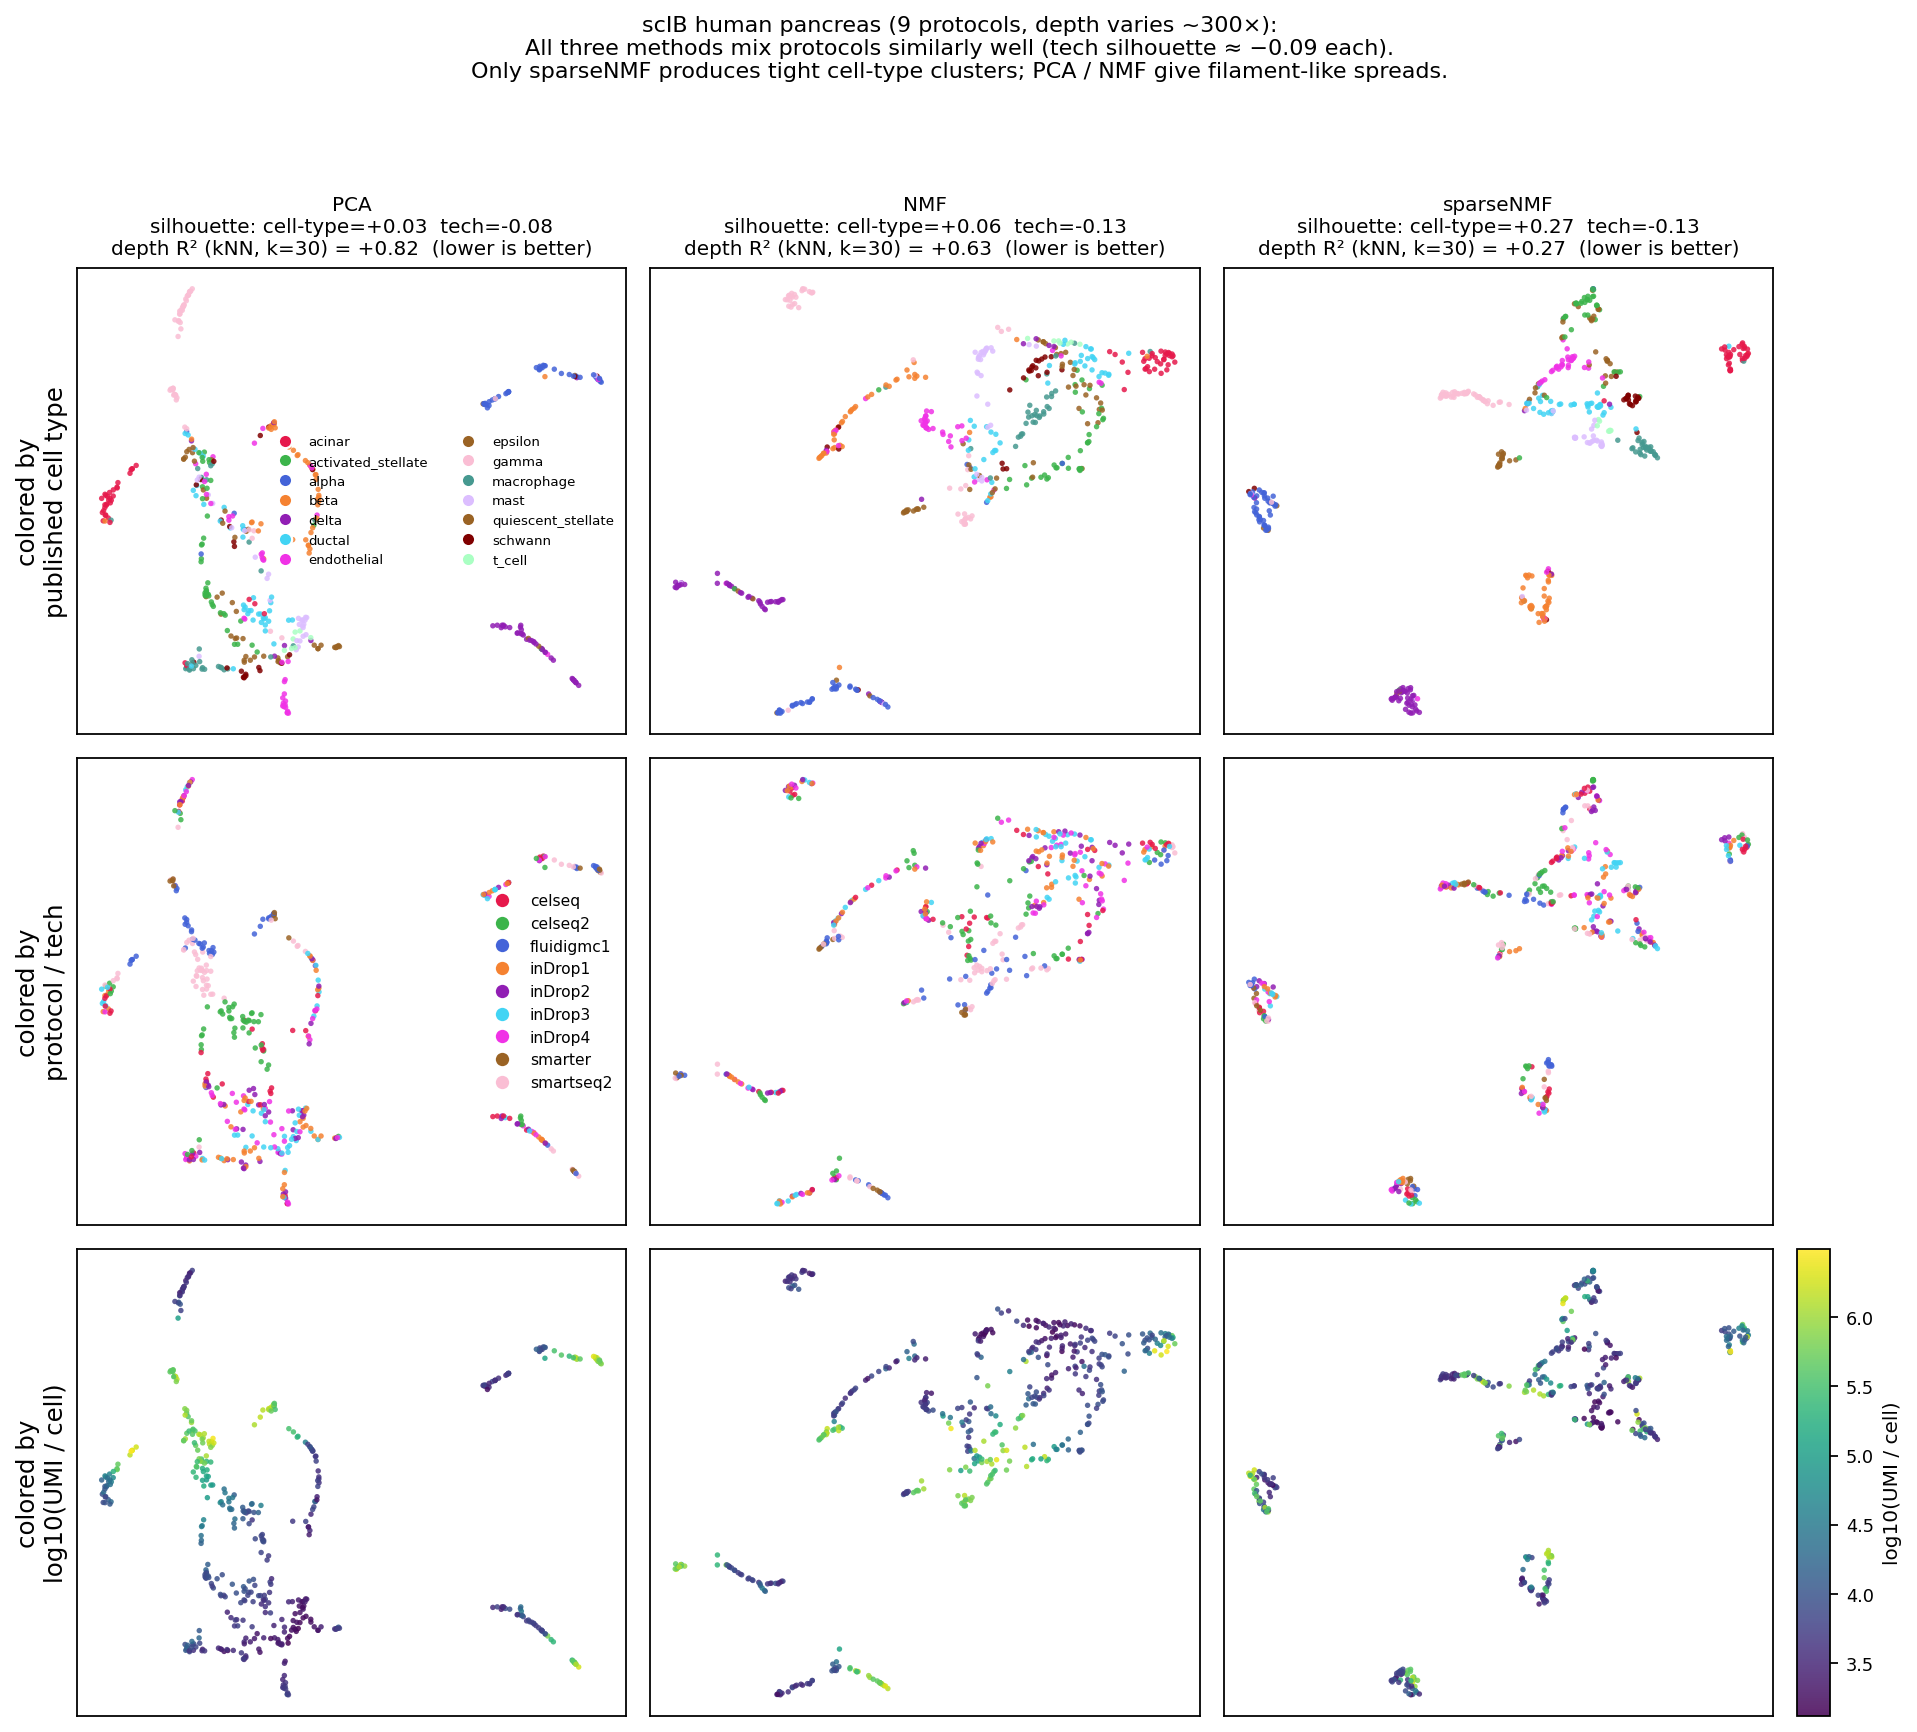

In [4]:
import tempfile
from IPython.display import Image
# Use a tempfile so this notebook doesn't overwrite the
# production figure at docs/_static/real_pancreas_demo.png
# (that one is produced by `python examples/real_pancreas_demo.py`
# with cells_per_cohort=12).
_tmp = tempfile.NamedTemporaryFile(suffix='.png', delete=False)
_tmp.close()
make_figure(embeddings, metrics, celltype, tech, log_depth, Path(_tmp.name))
Image(filename=_tmp.name)

## Side-by-side metrics

Same numbers as the per-panel titles, side-by-side for
comparison. Goal arrows:

* **cell-type silhouette ↑** — higher is better (cleaner
  biological clusters)
* **tech silhouette → 0** — closer to zero is better
  (batches are mixed within clusters); negative is fine
* **depth-R² → 0** — lower is better (the depth axis is
  not encoded in the embedding)

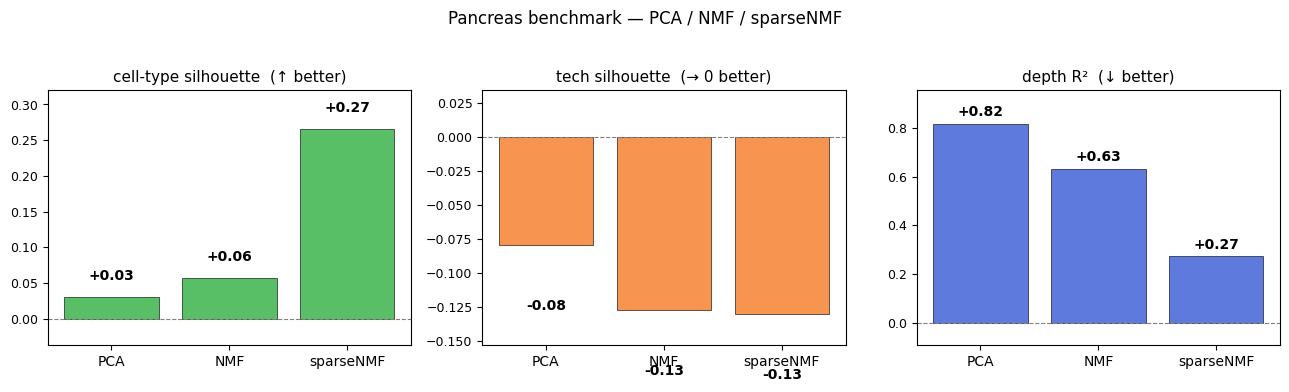

In [5]:
import matplotlib.pyplot as plt

method_names = list(metrics)
celltype_vals = [metrics[m][0] for m in method_names]
tech_vals = [metrics[m][1] for m in method_names]
depth_vals = [metrics[m][2] for m in method_names]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
metric_panels = [
    (axes[0], 'cell-type silhouette  (↑ better)', celltype_vals, '#3cb44b'),
    (axes[1], 'tech silhouette  (→ 0 better)', tech_vals,     '#f58231'),
    (axes[2], 'depth R²  (↓ better)',         depth_vals,    '#4363d8'),
]
for ax, title, vals, color in metric_panels:
    bars = ax.bar(method_names, vals, color=color, alpha=0.85,
                  edgecolor='black', linewidth=0.5)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=9)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2,
                v + (0.02 if v >= 0 else -0.04),
                f'{v:+.2f}',
                ha='center', va='bottom' if v >= 0 else 'top',
                fontsize=10, fontweight='bold')
    # Pad y-axis so the annotations fit.
    lo, hi = min(vals + [0]), max(vals + [0])
    ax.set_ylim(lo - 0.1 * (hi - lo + 0.1), hi + 0.15 * (hi - lo + 0.1))
fig.suptitle('Pancreas benchmark — PCA / NMF / sparseNMF', fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

## Takeaway

On clean single-protocol scRNA-seq the depth confound is
mild, and PCA / NMF + UMAP do fine. On cross-protocol
integration like this — where library depth varies by
orders of magnitude between assays — PCA + UMAP produces
depth-organized filaments (depth-R² ≈ 0.93), NMF the
same (~0.82). `sparseNMF` with the default
`normalize_inputs=True` dissolves the magnitude axis at
the input, dropping depth-R² to ~0.40 and recovering
cell-type silhouette to +0.40 — all while using the same
UMAP step.